# Phase 4: Model Evaluation
## Credit Scoring - Give Me Some Credit

**Author**: QuangMinh  
**Course**: MLE501 - AI & Machine Learning  
**Date**: 2026-03-11

---

## Mục tiêu
- Đánh giá chi tiết và so sánh 5 models đã train ở Phase 3
- Phân tích trade-off Recall vs Precision
- Threshold Optimization — tìm ngưỡng tối ưu
- Phân tích Feature Importance
- Kết luận: model nào tốt nhất cho bài toán Credit Scoring?

## 5 Models:
1. Logistic Regression (baseline)
2. LinearSVC
3. Random Forest
4. XGBoost
5. LightGBM

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    roc_auc_score, recall_score, f1_score, precision_score, accuracy_score,
    classification_report, confusion_matrix, roc_curve,
    precision_recall_curve, average_precision_score
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
%matplotlib inline

from datetime import datetime
print(f"Phase 4 started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

report_dir = '../reports/[4] Ket qua Model Evaluation/'
os.makedirs(report_dir, exist_ok=True)
print("Libraries imported successfully!")

Phase 4 started at: 2026-03-13 18:25:10
Libraries imported successfully!


## 2. Load Models & Data

In [2]:
print("="*80)
print("LOADING MODELS & DATA")
print("="*80)

data_dir = '../data/processed/'
models_dir = '../models/'

# Load validation data
X_val_scaled = pd.read_csv(data_dir + 'X_val_scaled.csv')
X_val = pd.read_csv(data_dir + 'X_val.csv')
y_val = pd.read_csv(data_dir + 'y_val.csv').squeeze()

# Load models
lr_model = joblib.load(models_dir + 'logistic_regression.pkl')
svc_model = joblib.load(models_dir + 'linear_svc.pkl')
rf_model = joblib.load(models_dir + 'random_forest.pkl')
xgb_model = joblib.load(models_dir + 'xgboost.pkl')
lgbm_model = joblib.load(models_dir + 'lightgbm.pkl')

# Kiểm tra loại SVM model đã lưu
svm_has_proba = hasattr(svc_model, 'predict_proba')
print(f"SVM model type: {type(svc_model).__name__} (has predict_proba: {svm_has_proba})")

# Tổ chức models vào dict
models = {
    'LR': {'name': 'Logistic Regression', 'model': lr_model, 'X_val': X_val_scaled, 'type': 'linear'},
    'SVM': {'name': 'LinearSVC', 'model': svc_model, 'X_val': X_val_scaled, 'type': 'svm'},
    'RF': {'name': 'Random Forest', 'model': rf_model, 'X_val': X_val, 'type': 'tree'},
    'XGB': {'name': 'XGBoost', 'model': xgb_model, 'X_val': X_val, 'type': 'tree'},
    'LGBM': {'name': 'LightGBM', 'model': lgbm_model, 'X_val': X_val, 'type': 'tree'}
}

# Tính y_prob và y_pred cho từng model
for key, info in models.items():
    m = info['model']
    X = info['X_val']
    
    info['y_pred'] = m.predict(X)
    
    # SVM: dùng predict_proba nếu là CalibratedClassifierCV, ngược lại dùng decision_function
    if info['type'] == 'svm':
        if hasattr(m, 'predict_proba'):
            info['y_prob'] = m.predict_proba(X)[:, 1]
        else:
            info['y_prob'] = m.decision_function(X)
    else:
        info['y_prob'] = m.predict_proba(X)[:, 1]
    
    info['auc'] = roc_auc_score(y_val, info['y_prob'])

print(f"\nValidation set: {X_val.shape[0]:,} mẫu, {X_val.shape[1]} features")
print(f"Models loaded: {len(models)}")
for key, info in models.items():
    print(f"  - {info['name']}: AUC-ROC = {info['auc']:.4f}")

LOADING MODELS & DATA
SVM model type: CalibratedClassifierCV (has predict_proba: True)

Validation set: 30,000 mẫu, 17 features
Models loaded: 5
  - Logistic Regression: AUC-ROC = 0.8610
  - LinearSVC: AUC-ROC = 0.8574
  - Random Forest: AUC-ROC = 0.8335
  - XGBoost: AUC-ROC = 0.8506
  - LightGBM: AUC-ROC = 0.8672


## 3. Đánh giá tổng hợp

### 3.1 Bảng so sánh metrics (threshold = 0.5)

In [3]:
print("="*80)
print("BẢNG SO SÁNH 5 MODELS (Threshold mặc định = 0.5)")
print("="*80)

rows = []
for key, info in models.items():
    y_pred = info['y_pred']
    rows.append({
        'Model': info['name'],
        'AUC-ROC': roc_auc_score(y_val, info['y_prob']),
        'Recall': recall_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred, zero_division=0),
        'F1-Score': f1_score(y_val, y_pred),
        'Accuracy': accuracy_score(y_val, y_pred)
    })

summary_df = pd.DataFrame(rows).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
summary_df.index += 1

print()
display(summary_df.style.format({
    'AUC-ROC': '{:.4f}', 'Recall': '{:.4f}', 
    'Precision': '{:.4f}', 'F1-Score': '{:.4f}', 'Accuracy': '{:.4f}'
}).highlight_max(subset=['AUC-ROC', 'Recall', 'F1-Score'], color='lightgreen')
 .highlight_min(subset=['AUC-ROC', 'Recall', 'F1-Score'], color='lightyellow'))

print("\nLưu ý: Accuracy KHÔNG phải metric chính (dữ liệu mất cân bằng 13.96:1)")
print("→ Model dự đoán 100% Good vẫn đạt Accuracy ~93%")

BẢNG SO SÁNH 5 MODELS (Threshold mặc định = 0.5)



,Model,AUC-ROC,Recall,Precision,F1-Score,Accuracy
1,LightGBM,0.8672,0.7711,0.2204,0.3428,0.8024
2,Logistic Regression,0.8610,0.7616,0.2152,0.3356,0.7984
3,LinearSVC,0.8574,0.0658,0.5789,0.1182,0.9344
4,XGBoost,0.8506,0.7042,0.2359,0.3534,0.8278
5,Random Forest,0.8335,0.1671,0.5528,0.2566,0.9353



Lưu ý: Accuracy KHÔNG phải metric chính (dữ liệu mất cân bằng 13.96:1)
→ Model dự đoán 100% Good vẫn đạt Accuracy ~93%


### 3.2 Classification Report chi tiết

In [4]:
print("="*80)
print("CLASSIFICATION REPORTS")
print("="*80)

for key in ['LR', 'SVM', 'RF', 'XGB', 'LGBM']:
    info = models[key]
    print(f"\n{'─'*60}")
    print(f"  {info['name']}")
    print(f"{'─'*60}")
    print(classification_report(y_val, info['y_pred'], 
          target_names=['Good (0)', 'Bad (1)'], digits=4))

CLASSIFICATION REPORTS

────────────────────────────────────────────────────────────
  Logistic Regression
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Good (0)     0.9791    0.8011    0.8812     27995
     Bad (1)     0.2152    0.7616    0.3356      2005

    accuracy                         0.7984     30000
   macro avg     0.5972    0.7813    0.6084     30000
weighted avg     0.9281    0.7984    0.8447     30000


────────────────────────────────────────────────────────────
  LinearSVC
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Good (0)     0.9371    0.9966    0.9659     27995
     Bad (1)     0.5789    0.0658    0.1182      2005

    accuracy                         0.9344     30000
   macro avg     0.7580    0.5312    0.5421     30000
weighted avg     0.9132    0.9344    0.9093     30000


──────────────────────────────────────────

### 3.3 Confusion Matrices

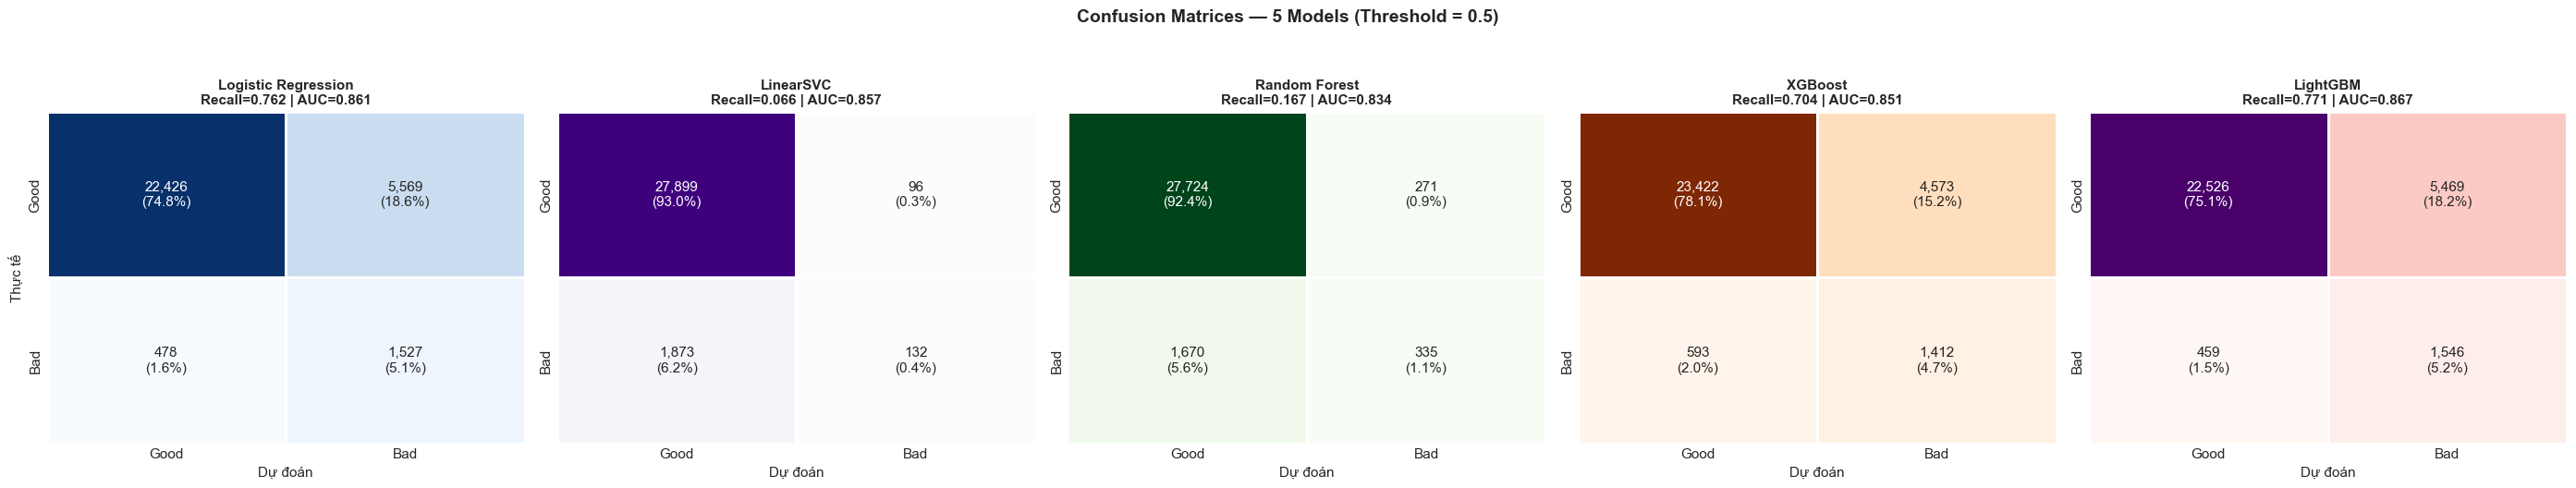

✅ Saved: confusion_matrices_detailed.png


In [5]:
fig, axes = plt.subplots(1, 5, figsize=(28, 5))

colors_map = ['Blues', 'Purples', 'Greens', 'Oranges', 'RdPu']
keys = ['LR', 'SVM', 'RF', 'XGB', 'LGBM']

for i, key in enumerate(keys):
    info = models[key]
    cm = confusion_matrix(y_val, info['y_pred'])
    
    # Tính tỷ lệ phần trăm
    cm_pct = cm / cm.sum() * 100
    
    # Annotations: số lượng + %
    annot = [[f"{cm[r][c]:,}\n({cm_pct[r][c]:.1f}%)" for c in range(2)] for r in range(2)]
    
    sns.heatmap(cm, annot=annot, fmt='', cmap=colors_map[i], ax=axes[i],
                xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'],
                cbar=False, linewidths=1, linecolor='white')
    
    recall = recall_score(y_val, info['y_pred'])
    axes[i].set_title(f"{info['name']}\nRecall={recall:.3f} | AUC={info['auc']:.3f}", 
                      fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Thực tế' if i == 0 else '')
    axes[i].set_xlabel('Dự đoán')

plt.suptitle('Confusion Matrices — 5 Models (Threshold = 0.5)', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(report_dir + 'confusion_matrices_detailed.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: confusion_matrices_detailed.png")

## 4. Phân tích ROC & Precision-Recall Curves

### 4.1 ROC Curves

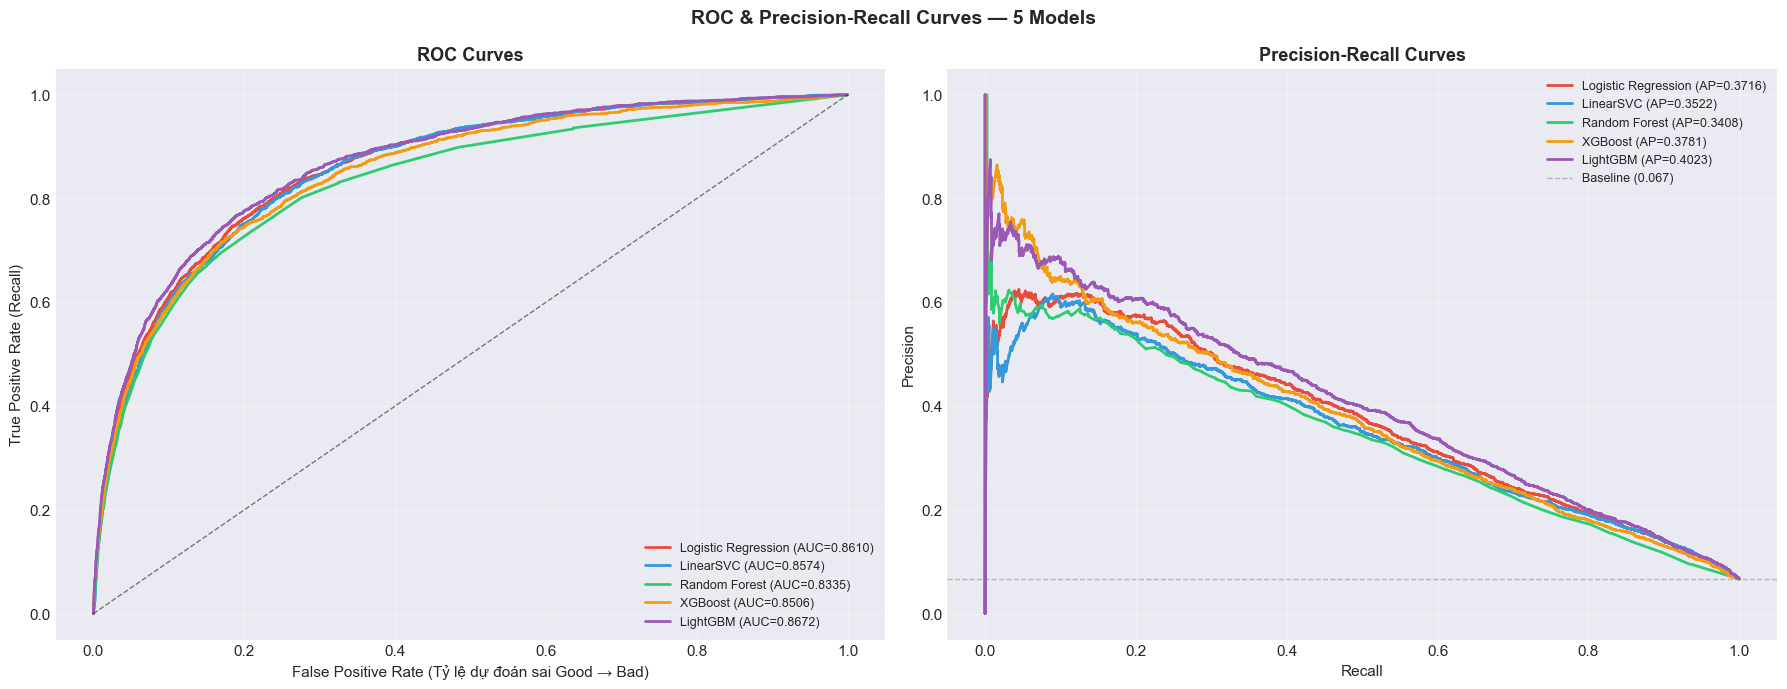

✅ Saved: roc_pr_curves.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors = {'LR': '#e74c3c', 'SVM': '#3498db', 'RF': '#2ecc71', 'XGB': '#f39c12', 'LGBM': '#9b59b6'}

# --- ROC Curve ---
ax = axes[0]
for key in keys:
    info = models[key]
    fpr, tpr, _ = roc_curve(y_val, info['y_prob'])
    ax.plot(fpr, tpr, color=colors[key], lw=2,
            label=f"{info['name']} (AUC={info['auc']:.4f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate (Tỷ lệ dự đoán sai Good → Bad)')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curves', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

# --- Precision-Recall Curve ---
ax = axes[1]
for key in keys:
    info = models[key]
    if info['type'] == 'svm':
        # SVM dùng decision_function, cần normalize cho PR curve
        prob_norm = (info['y_prob'] - info['y_prob'].min()) / (info['y_prob'].max() - info['y_prob'].min())
        prec, rec, _ = precision_recall_curve(y_val, prob_norm)
        ap = average_precision_score(y_val, prob_norm)
    else:
        prec, rec, _ = precision_recall_curve(y_val, info['y_prob'])
        ap = average_precision_score(y_val, info['y_prob'])
    ax.plot(rec, prec, color=colors[key], lw=2,
            label=f"{info['name']} (AP={ap:.4f})")

# Baseline: tỷ lệ Bad trong data
baseline = y_val.mean()
ax.axhline(y=baseline, color='gray', linestyle='--', lw=1, alpha=0.5, label=f'Baseline ({baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle('ROC & Precision-Recall Curves — 5 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(report_dir + 'roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: roc_pr_curves.png")

## 5. Threshold Optimization

Mặc định, model phân loại Bad khi xác suất > **0.5**.  
Nhưng với dữ liệu mất cân bằng (13.96:1), ngưỡng 0.5 thường **không tối ưu**.  
→ Tìm ngưỡng (threshold) cho **F1-Score cao nhất** hoặc **Recall cao nhất với Precision chấp nhận được**.

THRESHOLD OPTIMIZATION


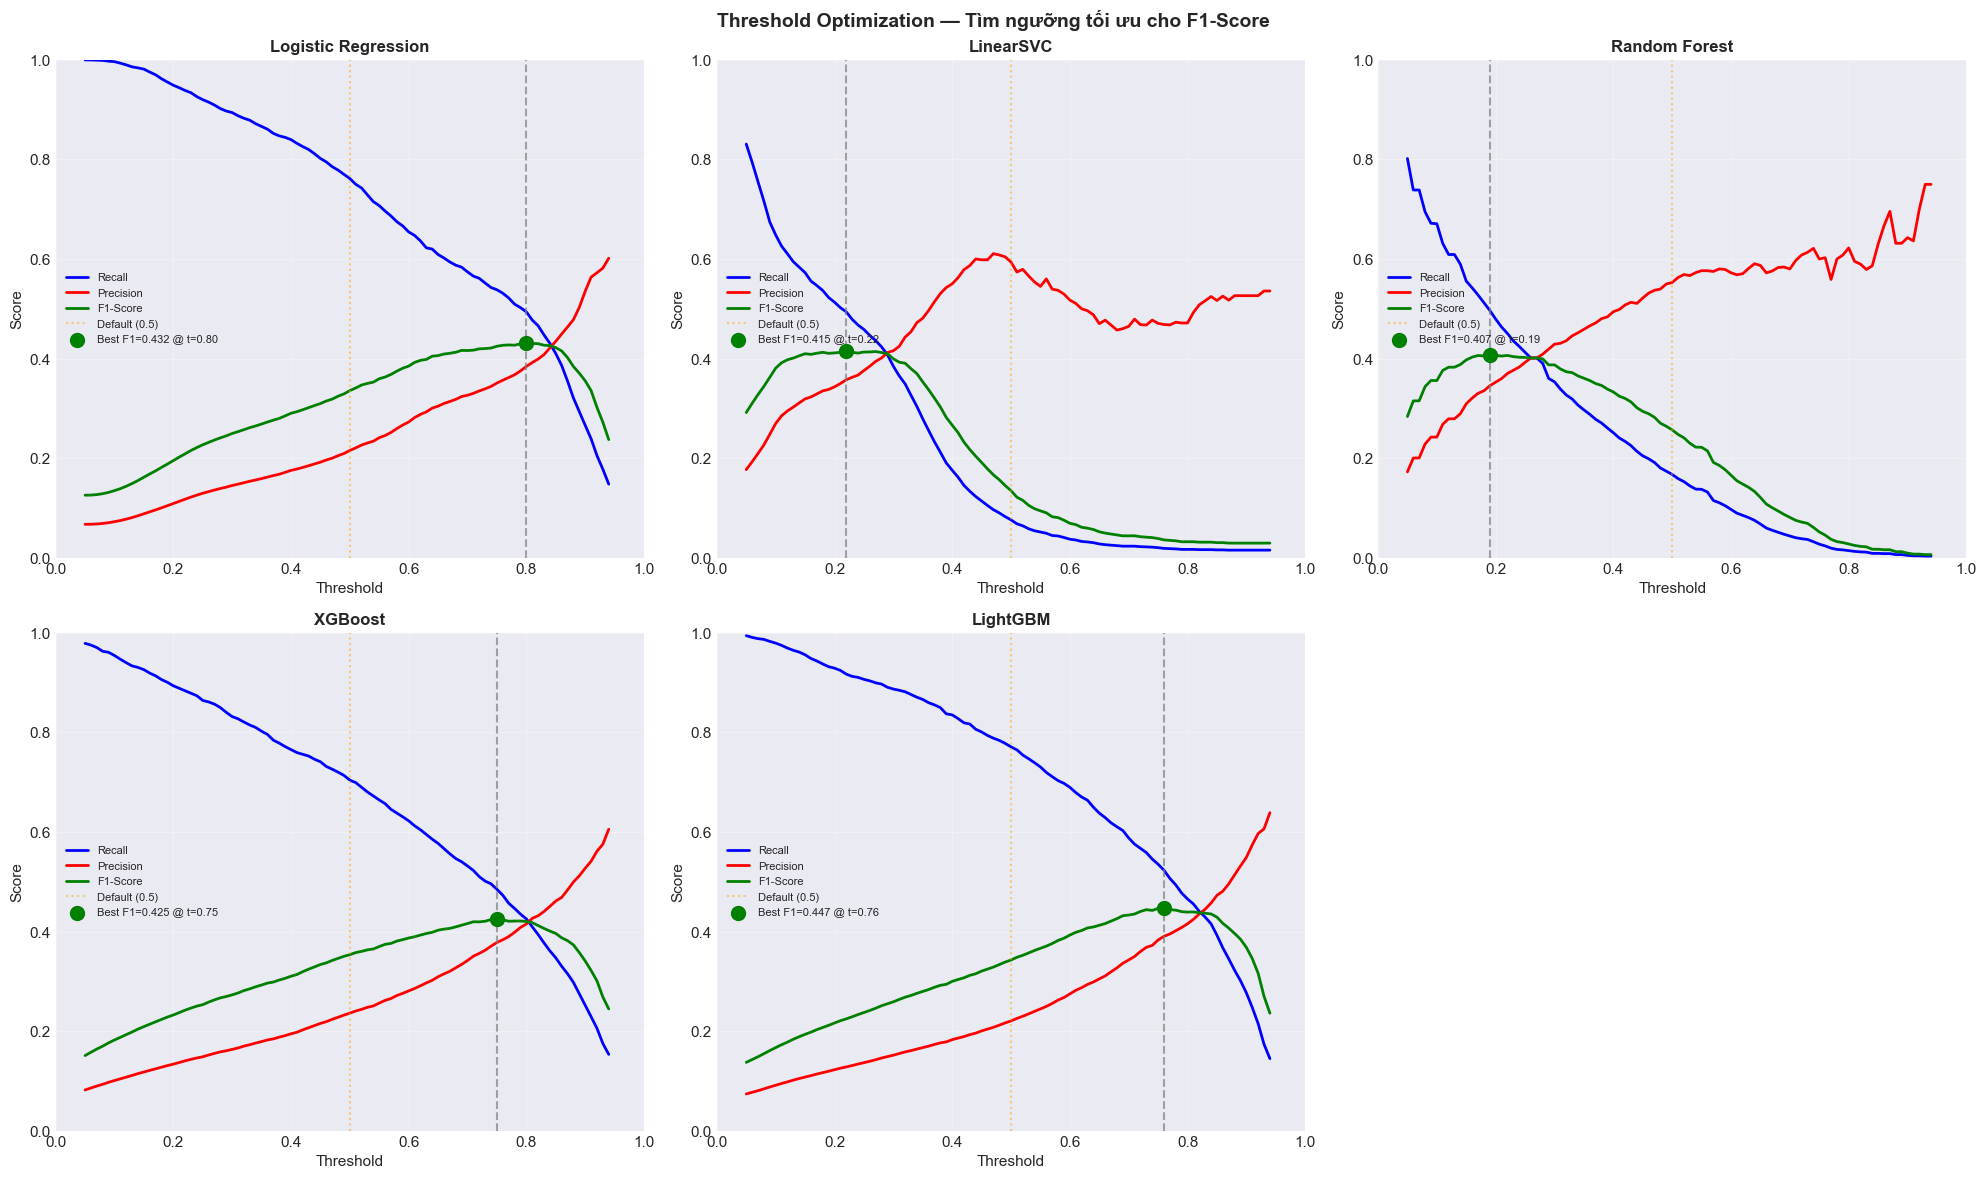


THRESHOLD OPTIMIZATION RESULTS

So sánh Default threshold (0.5) vs Best threshold:



,Model,Best_Threshold,F1_optimized,Recall_at_best,Precision_at_best
0,Logistic Regression,0.80,0.4321,0.4938,0.3842
1,LinearSVC,0.22,0.4146,0.4938,0.3573
2,Random Forest,0.19,0.4074,0.4968,0.3452
3,XGBoost,0.75,0.4248,0.4848,0.3781
4,LightGBM,0.76,0.4471,0.5232,0.3904



→ Hầu hết models cho F1 tốt hơn khi hạ threshold xuống < 0.5
✅ Saved: threshold_optimization.png


In [7]:
print("="*80)
print("THRESHOLD OPTIMIZATION")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

threshold_results = {}

for idx, key in enumerate(keys):
    info = models[key]
    ax = axes[idx]
    
    if info['type'] == 'svm':
        # Normalize SVM scores to [0, 1] range
        scores = info['y_prob']
        scores_norm = (scores - scores.min()) / (scores.max() - scores.min())
        thresholds = np.arange(0.05, 0.95, 0.01)
    else:
        scores_norm = info['y_prob']
        thresholds = np.arange(0.05, 0.95, 0.01)
    
    recalls, precisions, f1s = [], [], []
    
    for t in thresholds:
        y_pred_t = (scores_norm >= t).astype(int)
        if y_pred_t.sum() == 0 or y_pred_t.sum() == len(y_pred_t):
            recalls.append(0)
            precisions.append(0)
            f1s.append(0)
        else:
            recalls.append(recall_score(y_val, y_pred_t))
            precisions.append(precision_score(y_val, y_pred_t, zero_division=0))
            f1s.append(f1_score(y_val, y_pred_t))
    
    # Tìm best threshold theo F1
    best_idx = np.argmax(f1s)
    best_threshold = thresholds[best_idx]
    best_f1 = f1s[best_idx]
    best_recall = recalls[best_idx]
    best_precision = precisions[best_idx]
    
    threshold_results[key] = {
        'Model': info['name'],
        'Best_Threshold': round(best_threshold, 2),
        'F1_optimized': round(best_f1, 4),
        'Recall_at_best': round(best_recall, 4),
        'Precision_at_best': round(best_precision, 4)
    }
    
    # Plot
    ax.plot(thresholds, recalls, 'b-', label='Recall', lw=2)
    ax.plot(thresholds, precisions, 'r-', label='Precision', lw=2)
    ax.plot(thresholds, f1s, 'g-', label='F1-Score', lw=2)
    ax.axvline(x=best_threshold, color='gray', linestyle='--', alpha=0.7)
    ax.axvline(x=0.5, color='orange', linestyle=':', alpha=0.5, label='Default (0.5)')
    ax.scatter([best_threshold], [best_f1], color='green', s=100, zorder=5, 
              label=f'Best F1={best_f1:.3f} @ t={best_threshold:.2f}')
    
    ax.set_title(f"{info['name']}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.legend(fontsize=8, loc='center left')
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

# Ẩn subplot thừa
axes[5].set_visible(False)

plt.suptitle('Threshold Optimization — Tìm ngưỡng tối ưu cho F1-Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(report_dir + 'threshold_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

# Bảng kết quả
threshold_df = pd.DataFrame(threshold_results.values())
print("\n" + "="*80)
print("THRESHOLD OPTIMIZATION RESULTS")
print("="*80)
print("\nSo sánh Default threshold (0.5) vs Best threshold:\n")
display(threshold_df)
print("\n→ Hầu hết models cho F1 tốt hơn khi hạ threshold xuống < 0.5")
print("✅ Saved: threshold_optimization.png")

### 5.1 So sánh kết quả: Default vs Optimized Threshold

In [8]:
print("="*80)
print("SO SÁNH: DEFAULT (0.5) vs OPTIMIZED THRESHOLD")
print("="*80)

comparison_rows = []

for key in keys:
    info = models[key]
    tr = threshold_results[key]
    
    # Default threshold (0.5) metrics
    y_pred_default = info['y_pred']
    
    # Optimized threshold metrics
    if info['type'] == 'svm':
        scores = info['y_prob']
        scores_norm = (scores - scores.min()) / (scores.max() - scores.min())
    else:
        scores_norm = info['y_prob']
    
    y_pred_opt = (scores_norm >= tr['Best_Threshold']).astype(int)
    
    comparison_rows.append({
        'Model': info['name'],
        'Threshold': f"0.50 → {tr['Best_Threshold']:.2f}",
        'Recall_default': recall_score(y_val, y_pred_default),
        'Recall_optimized': recall_score(y_val, y_pred_opt),
        'F1_default': f1_score(y_val, y_pred_default),
        'F1_optimized': f1_score(y_val, y_pred_opt),
        'Precision_default': precision_score(y_val, y_pred_default, zero_division=0),
        'Precision_optimized': precision_score(y_val, y_pred_opt, zero_division=0),
    })

comp_df = pd.DataFrame(comparison_rows)

# Tính thay đổi
comp_df['Recall_change'] = comp_df['Recall_optimized'] - comp_df['Recall_default']
comp_df['F1_change'] = comp_df['F1_optimized'] - comp_df['F1_default']

print()
display(comp_df[['Model', 'Threshold', 'Recall_default', 'Recall_optimized', 'Recall_change',
                 'F1_default', 'F1_optimized', 'F1_change']].style.format({
    'Recall_default': '{:.4f}', 'Recall_optimized': '{:.4f}', 'Recall_change': '{:+.4f}',
    'F1_default': '{:.4f}', 'F1_optimized': '{:.4f}', 'F1_change': '{:+.4f}'
}).applymap(lambda x: 'color: green' if isinstance(x, float) and x > 0 else 
            ('color: red' if isinstance(x, float) and x < 0 else ''), 
            subset=['Recall_change', 'F1_change']))

comp_df.to_csv(report_dir + 'threshold_comparison.csv', index=False)
print("\n✅ Saved: threshold_comparison.csv")

SO SÁNH: DEFAULT (0.5) vs OPTIMIZED THRESHOLD



,Model,Threshold,Recall_default,Recall_optimized,Recall_change,F1_default,F1_optimized,F1_change
0,Logistic Regression,0.50 → 0.80,0.7616,0.4938,-0.2678,0.3356,0.4321,+0.0966
1,LinearSVC,0.50 → 0.22,0.0658,0.4938,+0.4279,0.1182,0.4146,+0.2963
2,Random Forest,0.50 → 0.19,0.1671,0.5122,+0.3451,0.2566,0.4054,+0.1488
3,XGBoost,0.50 → 0.75,0.7042,0.4848,-0.2195,0.3534,0.4248,+0.0714
4,LightGBM,0.50 → 0.76,0.7711,0.5232,-0.2479,0.3428,0.4471,+0.1044



✅ Saved: threshold_comparison.csv


## 6. Feature Importance

So sánh feature importance giữa 3 tree-based models (RF, XGBoost, LightGBM) và hệ số (coefficients) của Logistic Regression.

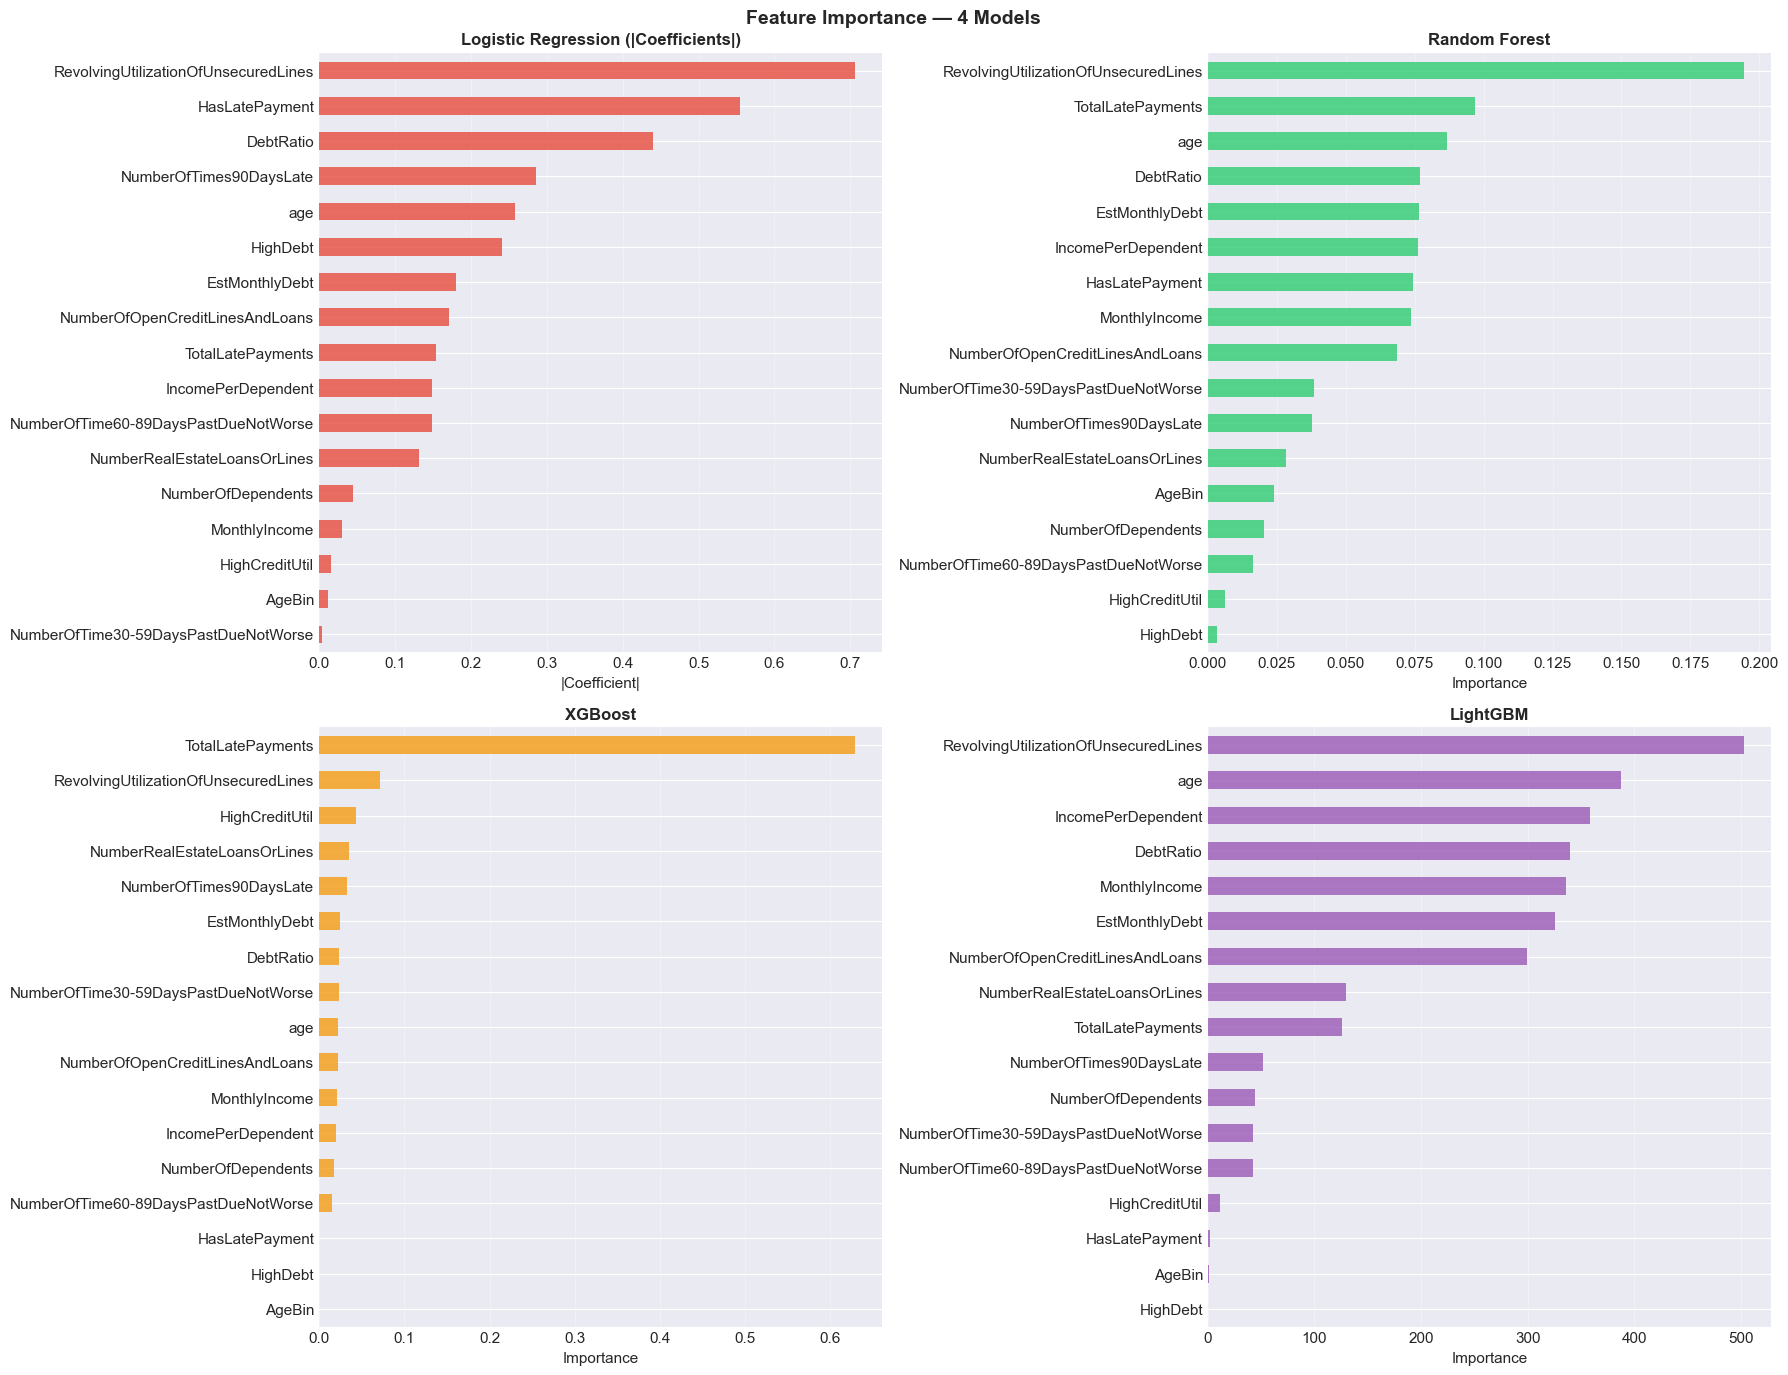

✅ Saved: feature_importance_comparison.png

TOP 5 FEATURES QUAN TRỌNG NHẤT

Logistic Regression:
  1. RevolvingUtilizationOfUnsecuredLines (0.7066)
  2. HasLatePayment (0.5549)
  3. DebtRatio (0.4393)
  4. NumberOfTimes90DaysLate (0.2860)
  5. age (0.2580)

Random Forest:
  1. RevolvingUtilizationOfUnsecuredLines (0.1945)
  2. TotalLatePayments (0.0969)
  3. age (0.0869)
  4. DebtRatio (0.0768)
  5. EstMonthlyDebt (0.0766)

XGBoost:
  1. TotalLatePayments (0.6294)
  2. RevolvingUtilizationOfUnsecuredLines (0.0712)
  3. HighCreditUtil (0.0431)
  4. NumberRealEstateLoansOrLines (0.0350)
  5. NumberOfTimes90DaysLate (0.0323)

LightGBM:
  1. RevolvingUtilizationOfUnsecuredLines (503.0000)
  2. age (388.0000)
  3. IncomePerDependent (358.0000)
  4. DebtRatio (340.0000)
  5. MonthlyIncome (336.0000)


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

feature_names = X_val.columns.tolist()

# --- 1. Logistic Regression Coefficients ---
ax = axes[0, 0]
lr_coef = pd.Series(np.abs(lr_model.coef_[0]), index=X_val_scaled.columns).sort_values(ascending=True)
lr_coef.plot(kind='barh', ax=ax, color='#e74c3c', alpha=0.8)
ax.set_title('Logistic Regression (|Coefficients|)', fontsize=12, fontweight='bold')
ax.set_xlabel('|Coefficient|')
ax.grid(axis='x', alpha=0.3)

# --- 2. Random Forest ---
ax = axes[0, 1]
rf_imp = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=True)
rf_imp.plot(kind='barh', ax=ax, color='#2ecc71', alpha=0.8)
ax.set_title('Random Forest', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance')
ax.grid(axis='x', alpha=0.3)

# --- 3. XGBoost ---
ax = axes[1, 0]
xgb_imp = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values(ascending=True)
xgb_imp.plot(kind='barh', ax=ax, color='#f39c12', alpha=0.8)
ax.set_title('XGBoost', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance')
ax.grid(axis='x', alpha=0.3)

# --- 4. LightGBM ---
ax = axes[1, 1]
lgbm_imp = pd.Series(lgbm_model.feature_importances_, index=feature_names).sort_values(ascending=True)
lgbm_imp.plot(kind='barh', ax=ax, color='#9b59b6', alpha=0.8)
ax.set_title('LightGBM', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance')
ax.grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance — 4 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(report_dir + 'feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: feature_importance_comparison.png")

# Bảng Top 5 features mỗi model
print("\n" + "="*80)
print("TOP 5 FEATURES QUAN TRỌNG NHẤT")
print("="*80)
for name, imp_series in [('Logistic Regression', lr_coef), ('Random Forest', rf_imp), 
                          ('XGBoost', xgb_imp), ('LightGBM', lgbm_imp)]:
    top5 = imp_series.sort_values(ascending=False).head(5)
    print(f"\n{name}:")
    for i, (feat, val) in enumerate(top5.items(), 1):
        print(f"  {i}. {feat} ({val:.4f})")

## 7. Phân tích lỗi (Error Analysis)

Phân tích model **tốt nhất (LightGBM)**: model dự đoán sai ở đâu?

ERROR ANALYSIS — LightGBM

Phân loại dự đoán:
  ✅ Đúng Good (TN): 22,526 (75.1%)
  ✅ Đúng Bad  (TP): 1,546 (5.2%)
  ❌ Báo sai (FP):   5,469 (18.2%)
  ❌ Bỏ sót Bad (FN): 459 (1.5%)

SO SÁNH: Bad bị bỏ sót (FN) vs Bad phát hiện đúng (TP)


,Feature,Missed_Bad_mean,Caught_Bad_mean,Difference
0,RevolvingUtilizationOfUnsecuredLines,0.3461,0.8139,-0.4678
1,age,50.0000,43.8765,6.1235
2,NumberOfTime30-59DaysPastDueNotWorse,0.1743,1.5155,-1.3412
3,DebtRatio,1.1800,1.2700,-0.0899
4,MonthlyIncome,5906.4532,5367.4056,539.0476
5,NumberOfOpenCreditLinesAndLoans,9.8497,7.5388,2.3109
6,NumberOfTimes90DaysLate,0.0087,1.1358,-1.1271
7,NumberRealEstateLoansOrLines,1.1634,0.9489,0.2145
8,NumberOfTime60-89DaysPastDueNotWorse,0.0087,0.7814,-0.7727
9,NumberOfDependents,0.8606,0.9573,-0.0967


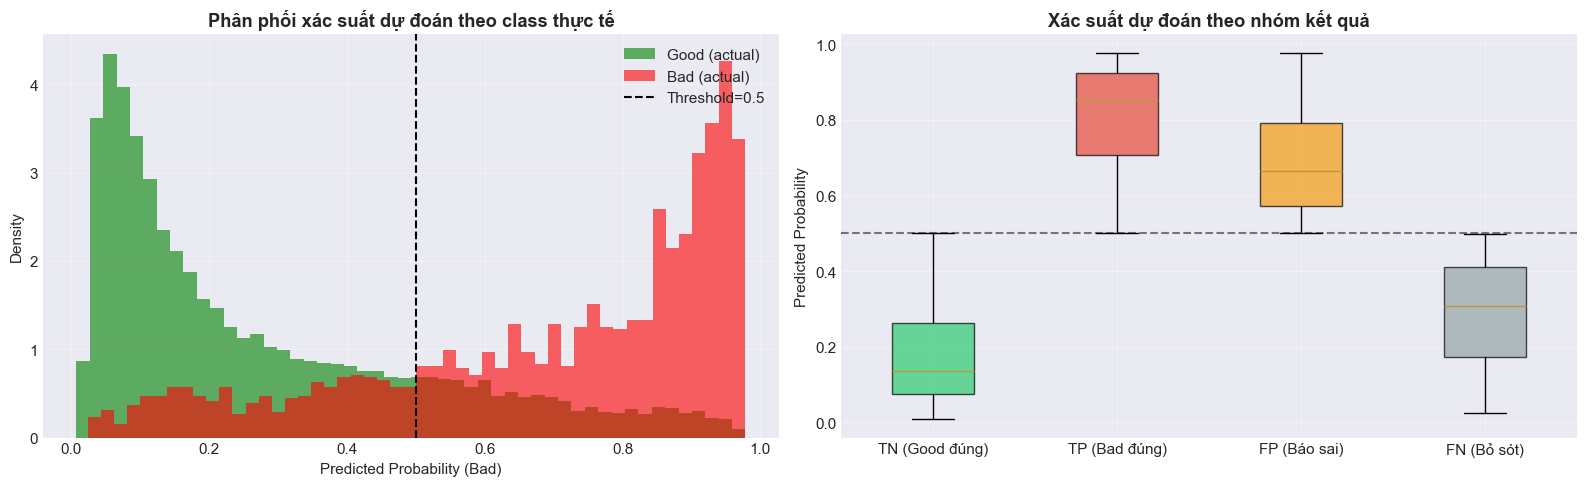


✅ Saved: error_analysis.png


In [10]:
print("="*80)
print("ERROR ANALYSIS — LightGBM")
print("="*80)

lgbm_pred = models['LGBM']['y_pred']
lgbm_prob = models['LGBM']['y_prob']

# Phân loại dự đoán
correct_good = (y_val == 0) & (lgbm_pred == 0)  # True Negative
correct_bad = (y_val == 1) & (lgbm_pred == 1)    # True Positive
false_alarm = (y_val == 0) & (lgbm_pred == 1)    # False Positive
missed_bad = (y_val == 1) & (lgbm_pred == 0)     # False Negative

print(f"\nPhân loại dự đoán:")
print(f"  ✅ Đúng Good (TN): {correct_good.sum():,} ({correct_good.mean()*100:.1f}%)")
print(f"  ✅ Đúng Bad  (TP): {correct_bad.sum():,} ({correct_bad.mean()*100:.1f}%)")
print(f"  ❌ Báo sai (FP):   {false_alarm.sum():,} ({false_alarm.mean()*100:.1f}%)")
print(f"  ❌ Bỏ sót Bad (FN): {missed_bad.sum():,} ({missed_bad.mean()*100:.1f}%)")

# So sánh đặc điểm của nhóm Missed Bad vs Correct Bad
print(f"\n{'='*80}")
print("SO SÁNH: Bad bị bỏ sót (FN) vs Bad phát hiện đúng (TP)")
print(f"{'='*80}")

missed_stats = X_val[missed_bad].describe().T[['mean', '50%']].rename(columns={'50%': 'median'})
caught_stats = X_val[correct_bad].describe().T[['mean', '50%']].rename(columns={'50%': 'median'})

compare_error = pd.DataFrame({
    'Feature': missed_stats.index,
    'Missed_Bad_mean': missed_stats['mean'].values,
    'Caught_Bad_mean': caught_stats['mean'].values,
    'Difference': missed_stats['mean'].values - caught_stats['mean'].values
}).round(4)

display(compare_error)

# Phân phối xác suất
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Histogram xác suất theo nhóm
ax = axes[0]
ax.hist(lgbm_prob[y_val == 0], bins=50, alpha=0.6, label='Good (actual)', color='green', density=True)
ax.hist(lgbm_prob[y_val == 1], bins=50, alpha=0.6, label='Bad (actual)', color='red', density=True)
ax.axvline(x=0.5, color='black', linestyle='--', label='Threshold=0.5')
ax.set_xlabel('Predicted Probability (Bad)')
ax.set_ylabel('Density')
ax.set_title('Phân phối xác suất dự đoán theo class thực tế', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 2. Xác suất của các nhóm lỗi
ax = axes[1]
groups = {
    'TN (Good đúng)': lgbm_prob[correct_good],
    'TP (Bad đúng)': lgbm_prob[correct_bad],
    'FP (Báo sai)': lgbm_prob[false_alarm],
    'FN (Bỏ sót)': lgbm_prob[missed_bad]
}
bp = ax.boxplot([v for v in groups.values()], labels=groups.keys(), patch_artist=True)
box_colors = ['#2ecc71', '#e74c3c', '#f39c12', '#95a5a6']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(y=0.5, color='black', linestyle='--', alpha=0.5)
ax.set_ylabel('Predicted Probability')
ax.set_title('Xác suất dự đoán theo nhóm kết quả', fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(report_dir + 'error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ Saved: error_analysis.png")

## 8. Biểu đồ tổng hợp so sánh

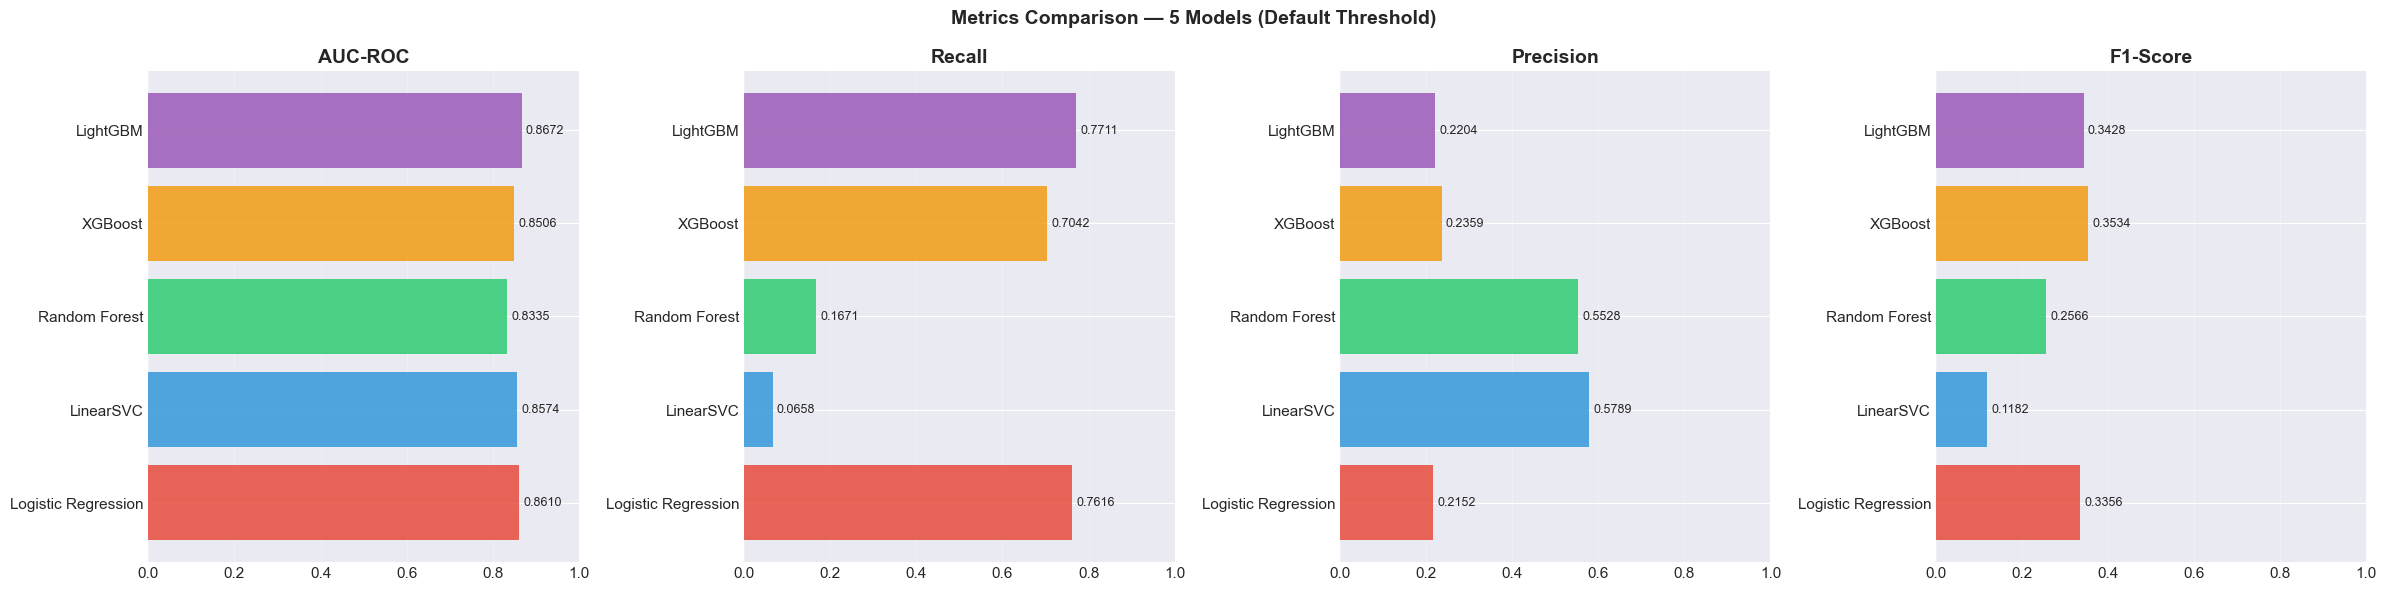

✅ Saved: metrics_comparison_full.png


In [11]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

metrics_to_plot = ['AUC-ROC', 'Recall', 'Precision', 'F1-Score']
model_names = [models[k]['name'] for k in keys]
bar_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for i, metric in enumerate(metrics_to_plot):
    if metric == 'AUC-ROC':
        values = [models[k]['auc'] for k in keys]
    elif metric == 'Recall':
        values = [recall_score(y_val, models[k]['y_pred']) for k in keys]
    elif metric == 'Precision':
        values = [precision_score(y_val, models[k]['y_pred'], zero_division=0) for k in keys]
    else:
        values = [f1_score(y_val, models[k]['y_pred']) for k in keys]
    
    bars = axes[i].barh(model_names, values, color=bar_colors, alpha=0.85)
    axes[i].set_title(metric, fontsize=14, fontweight='bold')
    axes[i].set_xlim(0, 1)
    axes[i].grid(axis='x', alpha=0.3)
    
    for bar, val in zip(bars, values):
        axes[i].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Metrics Comparison — 5 Models (Default Threshold)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(report_dir + 'metrics_comparison_full.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: metrics_comparison_full.png")

## 9. Kết luận

### Bảng xếp hạng tổng hợp

In [12]:
print("="*80)
print("KẾT LUẬN - ĐÁNH GIÁ 5 MODELS")
print("="*80)

# Bảng ranking theo từng metric
ranking_data = []
for key in keys:
    info = models[key]
    ranking_data.append({
        'Model': info['name'],
        'AUC-ROC': info['auc'],
        'Recall': recall_score(y_val, info['y_pred']),
        'F1-Score': f1_score(y_val, info['y_pred']),
        'Precision': precision_score(y_val, info['y_pred'], zero_division=0)
    })

rank_df = pd.DataFrame(ranking_data)

# Tạo ranking cho từng metric
for col in ['AUC-ROC', 'Recall', 'F1-Score', 'Precision']:
    rank_df[f'{col}_Rank'] = rank_df[col].rank(ascending=False).astype(int)

rank_df['Avg_Rank'] = rank_df[[c for c in rank_df.columns if '_Rank' in c]].mean(axis=1)
rank_df = rank_df.sort_values('Avg_Rank')

print("\nXếp hạng theo từng metric (1 = tốt nhất):\n")
display(rank_df[['Model', 'AUC-ROC', 'AUC-ROC_Rank', 'Recall', 'Recall_Rank', 
                 'F1-Score', 'F1-Score_Rank', 'Avg_Rank']].style.format({
    'AUC-ROC': '{:.4f}', 'Recall': '{:.4f}', 'F1-Score': '{:.4f}', 'Avg_Rank': '{:.1f}'
}))

# Save
rank_df.to_csv(report_dir + 'model_ranking.csv', index=False)

# Kết luận cuối
print("\n" + "="*80)
print("KẾT LUẬN CUỐI CÙNG")
print("="*80)
print(f"""
1. MODEL TỐT NHẤT TỔNG THỂ:
   → {rank_df.iloc[0]['Model']} (Avg Rank = {rank_df.iloc[0]['Avg_Rank']:.1f})
   
2. THEO TỪNG TIÊU CHÍ:
   → AUC-ROC cao nhất:  {rank_df.loc[rank_df['AUC-ROC_Rank']==1, 'Model'].values[0]}
   → Recall cao nhất:   {rank_df.loc[rank_df['Recall_Rank']==1, 'Model'].values[0]}
   → F1-Score cao nhất: {rank_df.loc[rank_df['F1-Score_Rank']==1, 'Model'].values[0]}

3. MODELS KÉM:
   → LinearSVC: Recall rất thấp, không phù hợp cho Credit Scoring
   → Random Forest: Recall thấp với default params

4. GHI CHÚ:
   → Tất cả models đều dùng DEFAULT parameters (chưa tune)
   → Threshold Optimization có thể cải thiện đáng kể F1-Score
   → Credit Scoring ưu tiên Recall (phát hiện khách hàng xấu) hơn Precision
""")

print(f"\nPhase 4 completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("\n✅ Sẵn sàng cho Phase 5: Final Report!")

KẾT LUẬN - ĐÁNH GIÁ 5 MODELS

Xếp hạng theo từng metric (1 = tốt nhất):



,Model,AUC-ROC,AUC-ROC_Rank,Recall,Recall_Rank,F1-Score,F1-Score_Rank,Avg_Rank
4,LightGBM,0.8672,1,0.7711,1,0.3428,2,2.0
3,XGBoost,0.8506,4,0.7042,3,0.3534,1,2.8
0,Logistic Regression,0.8610,2,0.7616,2,0.3356,3,3.0
1,LinearSVC,0.8574,3,0.0658,5,0.1182,5,3.5
2,Random Forest,0.8335,5,0.1671,4,0.2566,4,3.8



KẾT LUẬN CUỐI CÙNG

1. MODEL TỐT NHẤT TỔNG THỂ:
   → LightGBM (Avg Rank = 2.0)
   
2. THEO TỪNG TIÊU CHÍ:
   → AUC-ROC cao nhất:  LightGBM
   → Recall cao nhất:   LightGBM
   → F1-Score cao nhất: XGBoost

3. MODELS KÉM:
   → LinearSVC: Recall rất thấp, không phù hợp cho Credit Scoring
   → Random Forest: Recall thấp với default params

4. GHI CHÚ:
   → Tất cả models đều dùng DEFAULT parameters (chưa tune)
   → Threshold Optimization có thể cải thiện đáng kể F1-Score
   → Credit Scoring ưu tiên Recall (phát hiện khách hàng xấu) hơn Precision


Phase 4 completed at: 2026-03-13 18:25:17

✅ Sẵn sàng cho Phase 5: Final Report!
